# Assignment 5 — Timeseries **or** Text

**DATAX504** · Due end of Week 10

Choose **one** track. Delete or leave unused the other section. Less scaffolding is intentional: design choices are part of the work.

| Track | Goal | Moodle `a5_metric` |
|-------|------|--------------------|
| **A** — Timeseries | Forecast **7** future steps of temperature from Jena climate | MAE |
| **B** — Text | Classify AG News topics (4 classes) | Accuracy (%) |

## Tasks (whichever track)
1. Prepare inputs (windowing **or** tokenisation / vectorisation)
2. Train a sequence model appropriate to the track
3. Report the metric above
4. Short written answers: architecture + how inputs were prepared

## Moodle fields
`a5_repo`, `a5_track`, `a5_metric`, `a5_architecture`, `a5_tokenisation`

## AI disclosure (required)
Fill the table in the next cell before you submit.


## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model |OpenAI, GPT-5.6 Sol|
| Used for | Reviewing timeseries concepts, explaining code, and checking the assignment workflow.|
| Verified how | I ran all notebook cells, checked the data shapes, training/validation curves, and final test MAE.|
| Not used for | Inventing accuracy values, replacing the execution and verification of the notebook, or directly generating written conclusions.|


In [1]:
TRACK = "A"  # "A" or "B" — Moodle a5_track

import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

print("Selected track:", TRACK)


Selected track: A


---
# Track A — Timeseries (Jena)

Forecast the next **7** steps of `T (degC)` from a past window of observations.

You decide: lookback length, normalisation, train/val/test split, LSTM vs Conv1D vs other, and how you compute MAE on the original °C scale.


In [2]:
# Track A: download and load the Jena climate dataset
if TRACK == "A":
    import pandas as pd
    from zipfile import ZipFile

    uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"

    zip_path = keras.utils.get_file(
        origin=uri,
        fname="jena_climate_2009_2016.csv.zip"
    )

    with ZipFile(zip_path) as zip_file:
        zip_file.extractall()

    csv_path = "jena_climate_2009_2016.csv"

    df = pd.read_csv(csv_path)

    print(df.shape)
    print(df.head())

else:
    print("Skipping Track A")


(420551, 15)
             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.75     

In [3]:
# Select the temperature series and check missing values
temperature = df["T (degC)"].astype("float32").to_numpy()

print("Temperature shape:", temperature.shape)
print("Missing values:", np.isnan(temperature).sum())
print("First 5 temperatures:", temperature[:5])

Temperature shape: (420551,)
Missing values: 0
First 5 temperatures: [-8.02 -8.41 -8.51 -8.31 -8.27]


In [4]:
# Split the temperature series in chronological order
n = len(temperature)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_temp = temperature[:train_end]
val_temp = temperature[train_end:val_end]
test_temp = temperature[val_end:]

print("Train:", train_temp.shape)
print("Validation:", val_temp.shape)
print("Test:", test_temp.shape)

Train: (294385,)
Validation: (63083,)
Test: (63083,)


In [5]:
# Normalise using statistics from the training portion only
train_mean = train_temp.mean()
train_std = train_temp.std()

train_norm = (train_temp - train_mean) / train_std
val_norm = (val_temp - train_mean) / train_std
test_norm = (test_temp - train_mean) / train_std

print("Train mean:", train_mean)
print("Train std:", train_std)
print("Normalised train mean:", train_norm.mean())
print("Normalised train std:", train_norm.std())

Train mean: 9.107596
Train std: 8.654227
Normalised train mean: 6.634594e-09
Normalised train std: 1.0


In [6]:
# Build sliding windows: past 72 temperatures -> next 7 temperatures
LOOKBACK = 72
HORIZON = 7

def make_windows(series, lookback=LOOKBACK, horizon=HORIZON):
    n_samples = len(series) - lookback - horizon + 1

    X = np.empty((n_samples, lookback, 1), dtype=np.float32)
    y = np.empty((n_samples, horizon), dtype=np.float32)

    for i in range(n_samples):
        X[i, :, 0] = series[i:i + lookback]
        y[i] = series[i + lookback:i + lookback + horizon]

    return X, y


X_train, y_train = make_windows(train_norm)
X_val, y_val = make_windows(val_norm)
X_test, y_test = make_windows(test_norm)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (294307, 72, 1)
y_train: (294307, 7)
X_val: (63005, 72, 1)
y_val: (63005, 7)
X_test: (63005, 72, 1)
y_test: (63005, 7)


In [7]:
# Build a simple LSTM model for 7-step forecasting
model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, 1)),
    layers.LSTM(32),
    layers.Dense(HORIZON)
])

model.compile(
    optimizer="adam",
    loss="mae",
    metrics=["mae"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,583 (17.90 KB)

 Trainable params: 4,583 (17.90 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.0849 - mae: 0.0849 - val_loss: 0.0502 - val_mae: 0.0502
Epoch 2/20
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.0478 - mae: 0.0478 - val_loss: 0.0464 - val_mae: 0.0464
Epoch 3/20
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.0453 - mae: 0.0453 - val_loss: 0.0449 - val_mae: 0.0449
Epoch 4/20
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0442 - mae: 0.0442 - val_loss: 0.0442 - val_mae: 0.0442
Epoch 5/20
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0436 - mae: 0.0436 - val_loss: 0.0435 - val_mae: 0.0435
Epoch 6/20
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.0432 - mae: 0.0432 - val_loss: 0.0431 - val_mae: 0.0431
Epoch 7/20
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.0430 - mae: 0.0430 - val_loss: 0.0432 - val_mae: 0.0432
Epoch 8/20
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.0428 - mae: 0.0428 - val_loss: 0.0428 - val_mae: 0.0428
Epoch 9/20
1150/1150 ━━━

In [9]:
pred_norm = model.predict(X_test, verbose=0)

pred_c = pred_norm * train_std + train_mean
y_test_c = y_test * train_std + train_mean

metric = np.mean(np.abs(pred_c - y_test_c))

print("Track A MAE (Moodle a5_metric):", metric)

Track A MAE (Moodle a5_metric): 0.353987


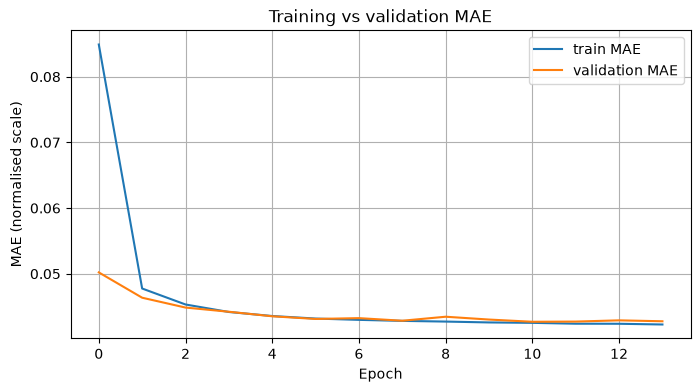

In [10]:
plt.figure(figsize=(8, 4))

plt.plot(history.history["mae"], label="train MAE")
plt.plot(history.history["val_mae"], label="validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE (normalised scale)")
plt.title("Training vs validation MAE")
plt.legend()
plt.grid(True)

plt.show()

---
## Written responses

### Architecture summary (Moodle `a5_architecture`, max 100 words)

*Layers, sizes, and why this design fits your track.*

### Input preparation (Moodle `a5_tokenisation`, max 100 words)

*Windowing / normalisation **or** tokenisation / padding / masking — whichever applies.*


**Model architecture summary**

I used a simple Sequential model with one LSTM layer containing 32 units, followed by a Dense layer with 7 outputs. The LSTM reads the past temperature sequence and learns temporal patterns from it. The Dense layer produces the next 7 temperature predictions at the same time. The model was trained with the Adam optimiser and mean absolute error (MAE) loss. Early stopping was used to restore the best validation weights.

**How inputs were prepared**

I used the T (degC) column from the Jena climate dataset. The data was split chronologically into 70% training, 15% validation, and 15% test sets. Normalisation used only the mean and standard deviation from the training set. Sliding windows were then created using the previous 72 temperature readings as input and the following 7 readings as targets. The final test predictions were converted back to degrees Celsius before calculating MAE.
